In [ ]:
pip install pandas numpy matplotlib seaborn statsmodels xgboost scikit-learn scipy

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df.head()


,Date,District,Dengue_Cases,Temperature,Humidity,Rainfall_mm
0,1/1/2020,Dhaka,9,20.1,70,0.0
1,1/2/2020,Dhaka,10,21.7,73,0.0
2,1/3/2020,Dhaka,17,18.7,89,2.0
3,1/4/2020,Dhaka,22,19.2,84,18.0
4,1/5/2020,Dhaka,20,18.8,82,0.0


In [ ]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

# --------------------------------------------------
# 2. Define correct column names
# --------------------------------------------------
variables = {
    "Dengue Cases (overall period)": "Dengue_Cases",
    "Temperature (°C)": "Temperature",
    "Humidity (%)": "Humidity",
    "Rainfall (mm)": "Rainfall_mm"
}

# --------------------------------------------------
# 3. Compute descriptive statistics
# --------------------------------------------------
rows = []

for label, col in variables.items():
    if col not in df.columns:
        print(f"⚠ Column '{col}' not found — skipped")
        continue

    s = pd.to_numeric(df[col], errors="coerce").dropna()

    rows.append({
        "Characteristic": label,
        "Minimum": s.min(),
        "Maximum": s.max(),
        "Average (SD)": (
            f"{s.mean():,.0f} ({s.std():,.0f})"
            if "Dengue" in label
            else f"{s.mean():.2f} ({s.std():.2f})"
        ),
        "Skewness": s.skew(),
        "Kurtosis": s.kurt(),   # excess kurtosis
        "Median": s.median()
    })

desc_table = pd.DataFrame(rows)

# --------------------------------------------------
# 4. Formatting (paper-ready)
# --------------------------------------------------
desc_table["Minimum"] = desc_table["Minimum"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)
desc_table["Maximum"] = desc_table["Maximum"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)
desc_table["Skewness"] = desc_table["Skewness"].apply(lambda x: f"{x:.2f}")
desc_table["Kurtosis"] = desc_table["Kurtosis"].apply(lambda x: f"{x:.2f}")
desc_table["Median"] = desc_table["Median"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)

desc_table = desc_table[
    ["Characteristic", "Minimum", "Maximum", "Average (SD)", "Skewness", "Kurtosis", "Median"]
]

# --------------------------------------------------
# 5. Display output
# --------------------------------------------------
print("\nTable 1. Descriptive statistics of dengue cases and meteorological factors\n")
print(desc_table.to_string(index=False))



Table 1. Descriptive statistics of dengue cases and meteorological factors

               Characteristic Minimum Maximum  Average (SD) Skewness Kurtosis Median
Dengue Cases (overall period)    0.00   1,327     152 (227)     2.12     4.78  41.00
             Temperature (°C)   13.30   34.00  26.42 (4.19)    -0.73    -0.48  27.70
                 Humidity (%)   32.00   98.00 72.31 (10.83)    -0.45     0.17  73.00
                Rainfall (mm)    0.00  265.00  6.86 (21.36)     6.13    50.63   0.00


In [ ]:
from statsmodels.tsa.stattools import adfuller

y = df['Dengue_Cases']

# Run Augmented Dickey-Fuller test
adf_result = adfuller(y)

# Print results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for k, v in adf_result[4].items():
    print(f"  {k}: {v}")



ADF Statistic: -2.979227534329042
p-value: 0.036880352494986994
Critical Values:
  1%: -3.4339881389288407
  5%: -2.863147035877915
  10%: -2.567625533641975


In [ ]:
df.columns

Index(['Date', 'District', 'Dengue_Cases', 'Temperature', 'Humidity',
       'Rainfall_mm'],
      dtype='object')

Files saved as:
Daily_Dengue_TimeSeries_2020_2024.png
Daily_Dengue_TimeSeries_2020_2024.pdf


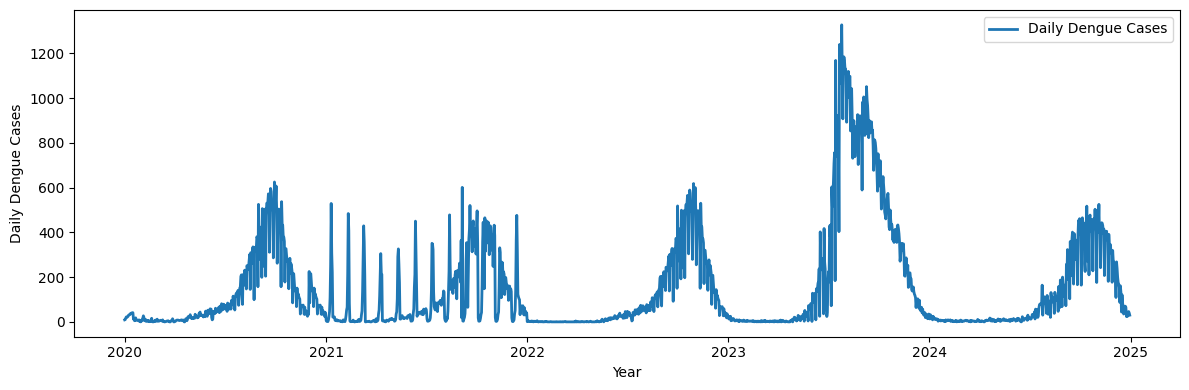

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --------------------------------------------------
# 1) Load Dataset
# --------------------------------------------------
file_path = "/content/dhaka_dengue_weather_2020_2024.csv"
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

y = df["Dengue_Cases"]

# --------------------------------------------------
# 2) Plot
# --------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(y.index, y.values, linewidth=2, label="Daily Dengue Cases")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xlabel("Year")
plt.ylabel("Daily Dengue Cases")
plt.legend()
plt.tight_layout()

# --------------------------------------------------
# 3) Save Files (PNG + PDF)
# --------------------------------------------------
png_filename = "Daily_Dengue_TimeSeries_2020_2024.png"
pdf_filename = "Daily_Dengue_TimeSeries_2020_2024.pdf"

#plt.savefig(png_filename, dpi=600, bbox_inches="tight")
#plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Files saved as:\n{png_filename}\n{pdf_filename}")

# --------------------------------------------------
# 4) Show Plot
# --------------------------------------------------
plt.show()


Heatmap saved as:
Dhaka_Dengue_Heatmap_2020_2024.png
Dhaka_Dengue_Heatmap_2020_2024.pdf


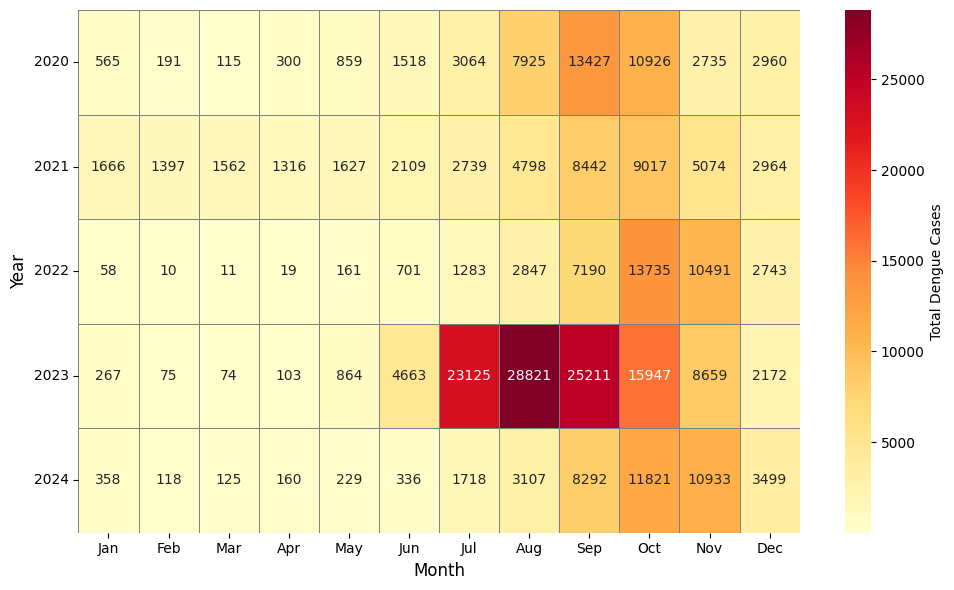

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────
# 1) Load and prepare data
# ────────────────────────────────────────────────
file_path = "/content/dhaka_dengue_weather_2020_2024.csv"
df = pd.read_csv(file_path)

# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract year and month
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")  # Jan, Feb, ..., Dec

# Aggregate dengue cases by Year-Month
monthly_cases = df.groupby(["Year", "Month", "Month_Name"])["Dengue_Cases"].sum().reset_index()

# ────────────────────────────────────────────────
# 2) Create pivot table for heatmap
#    rows = years, columns = months
# ────────────────────────────────────────────────
pivot = monthly_cases.pivot(
    index="Year",
    columns="Month",
    values="Dengue_Cases"
)

# Optional: fill missing months with 0 (if any month has no cases recorded)
pivot = pivot.fillna(0)

# To use month names instead of numbers on x-axis
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = month_names

# ────────────────────────────────────────────────
# 3) Create the heatmap
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,                # show numbers in cells
    fmt=".0f",                 # no decimal places
    cmap="YlOrRd",             # yellow → orange → red (good for cases)
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Total Dengue Cases"},
)

# Titles and labels
#plt.title("Dhaka Dengue Cases Heatmap (2020–2024)\nTotal Cases per Month", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Year", fontsize=12)

# Make sure years are shown as integers (not floats)
plt.yticks(rotation=0)

plt.tight_layout()

# ────────────────────────────────────────────────
# 4) Save high-quality versions
# ────────────────────────────────────────────────
png_filename = "Dhaka_Dengue_Heatmap_2020_2024.png"
pdf_filename = "Dhaka_Dengue_Heatmap_2020_2024.pdf"

#plt.savefig(png_filename, dpi=600, bbox_inches="tight")
#plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Heatmap saved as:\n{png_filename}\n{pdf_filename}")

# Show the plot
plt.show()

**For Download**

In [ ]:
!ls /content

Daily_Dengue_TimeSeries_2020_2024.pdf  dhaka_dengue_weather_2020_2024.csv
Daily_Dengue_TimeSeries_2020_2024.png  sample_data


In [ ]:
df.columns

Index(['Date', 'District', 'Dengue_Cases', 'Temperature', 'Humidity',
       'Rainfall_mm', 'Year', 'Month', 'Month_Name'],
      dtype='object')

In [ ]:
vars_for_corr = df[["Dengue_Cases", "Temperature","Humidity", "Rainfall_mm"]]


**Spearman Correlation**

In [ ]:
spearman_corr = vars_for_corr.corr(method="spearman")
spearman_corr

,Dengue_Cases,Temperature,Humidity,Rainfall_mm
Dengue_Cases,1.000000,0.244117,0.377296,0.167529
Temperature,0.244117,1.000000,0.138269,0.218686
Humidity,0.377296,0.138269,1.000000,0.456304
Rainfall_mm,0.167529,0.218686,0.456304,1.000000


**P-Value**

In [ ]:
from scipy.stats import spearmanr

rho, pval = spearmanr(vars_for_corr, nan_policy="omit")
p_values = pd.DataFrame(
    pval,
    index=vars_for_corr.columns,
    columns=vars_for_corr.columns
)

p_values

,Dengue_Cases,Temperature,Humidity,Rainfall_mm
Dengue_Cases,0.000000e+00,3.500530e-26,7.428482e-63,5.809551e-13
Temperature,3.500530e-26,0.000000e+00,2.975429e-09,3.290658e-21
Humidity,7.428482e-63,2.975429e-09,0.000000e+00,1.386879e-94
Rainfall_mm,5.809551e-13,3.290658e-21,1.386879e-94,0.000000e+00


**1.Standard Spearman Correlation Matrix (Same-Time Correlation)**

The standard Spearman correlation matrix represents the strength and direction of association between variables measured at the same time point. In this matrix, each variable is correlated with every other variable in the dataset without considering any temporal delay. Because each variable is perfectly correlated with itself, the diagonal elements of the matrix are equal to 1.00. This type of correlation matrix is commonly used for exploratory data analysis, allowing researchers to assess overall relationships and detect potential multicollinearity among predictors. For example, the correlation between dengue cases and humidity in the same time period reflects how strongly they vary together concurrently. However, for infectious diseases such as dengue, same-time correlations may underestimate the true environmental influence, as climatic factors often affect transmission dynamics after a delay rather than instantaneously.

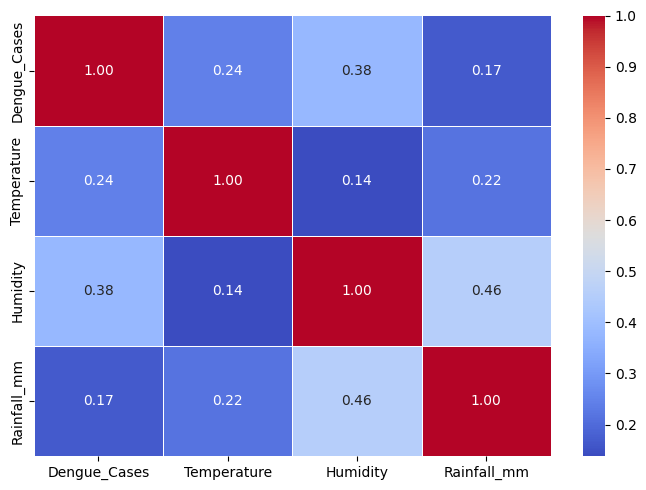

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# Choose variables (no lags here)
vars_for_corr = ["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]

corr_matrix = df[vars_for_corr].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
#plt.title("Spearman Correlation Matrix")

#plt.savefig("spearman_correlation_dhaka_dengue_weather.png", dpi=600, bbox_inches="tight")
#plt.savefig("spearman_correlation_dhaka_dengue_weather.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()


**Lag Feature Engineering for Dengue Forecasting**

To capture the delayed effects of both past dengue cases and climatic factors, lagged features were created using the .shift() function. For dengue cases, autoregressive lags of 7, 14, 21, and 30 days were generated to represent short-term temporal dependence, reflecting weekly transmission cycles and reporting patterns. These variables allow the model to incorporate recent historical trends in dengue incidence.

In addition, lagged climate variables (temperature, humidity, and rainfall) were created at 7, 14, 30, 45, and 60 days to account for the delayed biological impact of environmental conditions on mosquito breeding and virus transmission. Since climatic factors influence dengue transmission indirectly—through mosquito development, virus incubation, and human infection cycles—these delays typically range from two to eight weeks.

By adding these lagged variables, the time-series problem is transformed into a supervised machine learning framework, where the model predicts current dengue cases using both past dengue values and prior climatic conditions. Rows with missing values resulting from lag creation were removed before model training to ensure data integrity.

In [ ]:
# Dengue autoregressive lags
for lag in [7, 14, 21, 30]:
    df[f"Dengue_Lag{lag}"] = df["Dengue_Cases"].shift(lag)

# Climate lags
for lag in [7, 14, 30, 45, 60]:
    df[f"Humidity_Lag{lag}"] = df["Humidity"].shift(lag)
    df[f"Rainfall_Lag{lag}"] = df["Rainfall_mm"].shift(lag)
    df[f"Temperature_Lag{lag}"] = df["Temperature"].shift(lag)



In [ ]:
lag_days = [7, 14, 30, 45, 60]

results = []

for lag in lag_days:
    cols = [
        "Dengue_Cases",
        f"Temperature_Lag{lag}",
        f"Humidity_Lag{lag}",
        f"Rainfall_Lag{lag}"
    ]

    temp_df = df[cols].dropna()
    corr = temp_df.corr(method="spearman").iloc[0, 1:]

    results.append({
        "Lag (Days)": lag,
        "Temp Corr": corr[0],
        "Humidity Corr": corr[1],
        "Rainfall Corr": corr[2]
    })

corr_table = pd.DataFrame(results)
corr_table


/tmp/ipykernel_155/1680812217.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Temp Corr": corr[0],
/tmp/ipykernel_155/1680812217.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Humidity Corr": corr[1],
/tmp/ipykernel_155/1680812217.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "Rainfall Corr": corr[2]
/tmp/ipykernel_155/1680812217.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. I

,Lag (Days),Temp Corr,Humidity Corr,Rainfall Corr
0,7,0.319226,0.402329,0.241161
1,14,0.405338,0.405750,0.276063
2,30,0.533092,0.447074,0.342544
3,45,0.632078,0.433502,0.395267
4,60,0.691739,0.411139,0.399065


**P Value For Lagged Features**

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

lag_days = [7, 14, 30, 45, 60]
p_results = []

for lag in lag_days:

    cols = [
        "Dengue_Cases",
        f"Temperature_Lag{lag}",
        f"Humidity_Lag{lag}",
        f"Rainfall_Lag{lag}"
    ]

    temp_df = df[cols].dropna()

    # Extract only p-values (second output from spearmanr)
    _, temp_p = spearmanr(temp_df["Dengue_Cases"],
                          temp_df[f"Temperature_Lag{lag}"])

    _, hum_p = spearmanr(temp_df["Dengue_Cases"],
                         temp_df[f"Humidity_Lag{lag}"])

    _, rain_p = spearmanr(temp_df["Dengue_Cases"],
                          temp_df[f"Rainfall_Lag{lag}"])

    p_results.append({
        "Lag (Days)": lag,
        "Temp p-value": temp_p,
        "Humidity p-value": hum_p,
        "Rainfall p-value": rain_p
    })

p_table = pd.DataFrame(p_results)
p_table


,Lag (Days),Temp p-value,Humidity p-value,Rainfall p-value
0,7,2.286666e-44,9.897829e-72,1.757309e-25
1,14,1.318537e-72,9.175393e-73,4.706880e-33
2,30,2.007118e-132,5.705040e-89,1.308076e-50
3,45,2.807668e-199,1.679137e-82,1.127604e-67
4,60,1.135314e-251,5.436477e-73,1.702332e-68


**2.Lagged Spearman Correlation Heatmap (Delayed Effect Analysis**

The lagged Spearman correlation heatmap evaluates the relationship between current dengue cases and climate variables measured at earlier time points. Instead of correlating variables measured simultaneously, this approach incorporates biologically meaningful time delays (lags) such as 7, 14, 30, 45, and 60 days. This structure does not produce a square matrix and does not contain diagonal values of 1 because the analysis does not compare a variable with itself. Rather, it examines whether past climatic conditions influence present dengue incidence. This method is particularly important for vector-borne diseases, as mosquito breeding cycles, viral incubation periods, and environmental responses occur over time. The lagged heatmap therefore provides deeper epidemiological insight and is especially useful for identifying optimal lag periods for predictive modeling and forecasting.

Heatmap saved successfully.


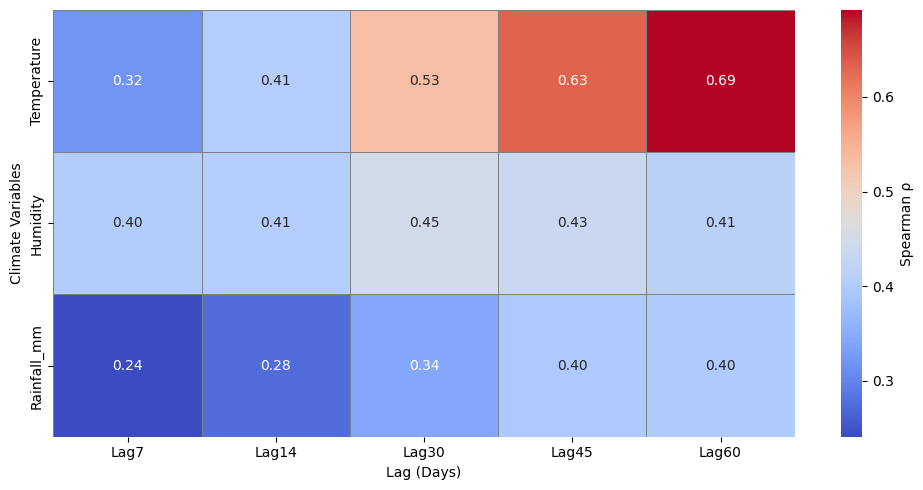

In [ ]:
# ==========================================================
#    Dengue Cases vs Climate Variables
# ==========================================================

# ----------------------------------------------------------
# 1) Import Libraries
# ----------------------------------------------------------
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 2) Load Dataset (Daily)
# ----------------------------------------------------------
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

# ----------------------------------------------------------
# 3) Define Biologically Meaningful Lags (Days)
# ----------------------------------------------------------
lag_days = [7, 14, 30, 45, 60]
climate_vars = ["Temperature", "Humidity", "Rainfall_mm"]

# ----------------------------------------------------------
# 4) Create Lagged Climate Variables
# ----------------------------------------------------------
for lag in lag_days:
    for var in climate_vars:
        df[f"{var}_Lag{lag}"] = df[var].shift(lag)

# ----------------------------------------------------------
# 5) Compute Spearman Correlation Matrix
#    Rows   = Climate Variables
#    Columns= Lag Days
# ----------------------------------------------------------
lag_corr = pd.DataFrame(
    index=climate_vars,
    columns=[f"Lag{d}" for d in lag_days],
    dtype=float
)

for var in climate_vars:
    for lag in lag_days:
        temp_df = df[["Dengue_Cases", f"{var}_Lag{lag}"]].dropna()
        lag_corr.loc[var, f"Lag{lag}"] = temp_df["Dengue_Cases"].corr(
            temp_df[f"{var}_Lag{lag}"],
            method="spearman"
        )

# ----------------------------------------------------------
# 6) Plot Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))

sns.heatmap(
    lag_corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="gray",
    fmt=".2f",
    cbar_kws={"label": "Spearman ρ"}
)

plt.xlabel("Lag (Days)")
plt.ylabel("Climate Variables")
#plt.title("Lagged Spearman Correlation Heatmap\n(Daily Dengue vs Climate Variables)")
plt.tight_layout()

# ----------------------------------------------------------
# 7) Save Files
# ----------------------------------------------------------
#plt.savefig("Lagged_Spearman_Correlation_Heatmap_Daily.png", dpi=600, bbox_inches="tight")
#plt.savefig("Lagged_Spearman_Correlation_Heatmap_Daily.pdf", format="pdf", bbox_inches="tight")

print("Heatmap saved successfully.")

plt.show()


**Selection of Optimal Lag Periods Based on Spearman Correlation**

Selection of Optimal Lag Periods Based on Spearman Correlation

To identify the most influential delayed effects of climatic variables on dengue incidence, Spearman rank correlation analysis was conducted using multiple lag periods (7, 14, 30, 45, and 60 days). The results indicate that temperature shows a progressively increasing correlation with dengue cases, reaching its highest association at a 60-day lag (ρ = 0.6917). This suggests that temperature exerts a strong delayed influence approximately two months prior to dengue incidence.

Humidity exhibits its strongest relationship at a 30-day lag (ρ = 0.4471), indicating a moderate delayed effect roughly one month before case occurrence. Rainfall shows increasing correlation up to 60 days (ρ = 0.3991), slightly stronger than at 45 days, implying that accumulated rainfall conditions approximately two months earlier contribute significantly to dengue transmission dynamics.

Based on these findings, the optimal lag structure selected for modeling includes:

**Temperature_Lag60**

**Humidity_Lag30**

**Rainfall_Lag45**

These lag selections align with biological mechanisms of dengue transmission, including mosquito breeding cycles, larval development, viral incubation, and human infection processes, which collectively produce delayed epidemiological effects ranging from several weeks to two months.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from itertools import product

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1) Load dataset

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")


# 2) Convert Date and build DAILY dengue series
#    - sums if multiple rows per day
#    - ensures all days exist (missing -> 0)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

y = (
    df.set_index("Date")
      .resample("D")["Dengue_Cases"]
      .sum()
      .asfreq("D", fill_value=0)
)

print("Freq:", y.index.inferred_freq)
print("Total days:", len(y))


# 3) 80/20 Chronological split

split_index = int(len(y) * 0.8)
train = y.iloc[:split_index]
test  = y.iloc[split_index:]

print("Train:", train.index.min(), "to", train.index.max(), "| n=", len(train))
print("Test :", test.index.min(),  "to", test.index.max(),  "| n=", len(test))


# 4) Metrics

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


# 5) SARIMA search space (DAILY)
#    Common daily seasonality: weekly = 7

s = 7  # weekly seasonality

p = [0, 1, 2]
d = [0, 1]
q = [0, 1, 2]
P = [0, 1, 2]
D = [0, 1]
Q = [0, 1, 2]

candidates = list(product(p, d, q, P, D, Q))[:60]


# 6) Fit + evaluate

results = []

for (p_, d_, q_, P_, D_, Q_) in candidates:
    try:
        model = SARIMAX(
            train,
            order=(p_, d_, q_),
            seasonal_order=(P_, D_, Q_, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        forecast = fit.get_forecast(steps=len(test)).predicted_mean
        forecast = forecast.clip(lower=0)

        results.append({
            "order": (p_, d_, q_),
            "seasonal_order": (P_, D_, Q_, s),
            "AIC": fit.aic,
            "RMSE": rmse(test, forecast),
            "MAE": mae(test, forecast),
            "SMAPE(%)": smape(test, forecast),
            "R2": r2_score(test, forecast)
        })

    except:
        continue

results_df = pd.DataFrame(results)
print(f"\n Successfully fitted {len(results_df)} combination SARIMA models")


# 7) Best model by RMSE

best = results_df.sort_values("RMSE").iloc[0]

print("\n Best Daily SARIMA (80/20 split) by RMSE")
print(best)


Freq: D
Total days: 1826
Train: 2020-01-01 00:00:00 to 2023-12-30 00:00:00 | n= 1460
Test : 2023-12-31 00:00:00 to 2024-12-30 00:00:00 | n= 366

 Successfully fitted 60 combination SARIMA models

 Best Daily SARIMA (80/20 split) by RMSE
order                (0, 0, 2)
seasonal_order    (2, 1, 2, 7)
AIC               16511.579425
RMSE                164.275983
MAE                 106.682576
SMAPE(%)             127.27946
R2                   -0.195802
Name: 53, dtype: object


In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 0) Imports
# ============================================================
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam


# ============================================================
# 1) Load & prepare data
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

target = "Dengue_Cases"


# 2) Create lag features (BASED ON  BEST LAGS)
#    Dengue lags: 7, 14, 30
#    Climate lags: Temp 60, Humidity 30, Rainfall 45

dengue_lags = [7, 14, 30]

df["Temperature_Lag60"] = df["Temperature"].shift(60)
df["Humidity_Lag30"]    = df["Humidity"].shift(30)
df["Rainfall_Lag45"]    = df["Rainfall_mm"].shift(45)

for lag in dengue_lags:
    df[f"Dengue_Lag{lag}"] = df[target].shift(lag)

features = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30",
]

# keep only rows where everything needed is present
df_ml = df.dropna(subset=[target] + features).copy()

X = df_ml[features].values
y = df_ml[target].values


# ============================================================
# 3) Train-test split (time-based)
# ============================================================
split_idx = int(len(df_ml) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


# ============================================================
# 4) Evaluation function (safe for zeros)
# ============================================================
def evaluate_model(name, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true = np.array(y_true, dtype=float)

    mask = y_true != 0
    mape = (
        np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        if mask.sum() else np.nan
    )

    denom = np.abs(y_true) + np.abs(y_pred)
    mask2 = denom != 0
    smape = (
        np.mean(200 * np.abs(y_pred[mask2] - y_true[mask2]) / denom[mask2])
        if mask2.sum() else np.nan
    )

    return {
        "Model": name,
        "RMSE": rmse,
        "MSE": mse,
        "MAE": mae,
        "MAPE (%)": mape,
        "SMAPE (%)": smape,
        "R2": r2
    }


results = []


# ============================================================
# 6) Linear Models
# ============================================================
lr = LinearRegression()
lr.fit(X_train, y_train)
results.append(evaluate_model("Linear Regression", y_test, lr.predict(X_test)))

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
results.append(evaluate_model("Ridge Regression", y_test, ridge.predict(X_test)))


# ============================================================
# 7) Tree-Based Models
# ============================================================
rf = RandomForestRegressor(n_estimators=400, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results.append(evaluate_model("Random Forest", y_test, rf.predict(X_test)))

etr = ExtraTreesRegressor(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1)
etr.fit(X_train, y_train)
results.append(evaluate_model("Extra Trees", y_test, etr.predict(X_test)))


# ============================================================
# 8) Boosting Models
# ============================================================
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
xgb.fit(X_train, y_train)
results.append(evaluate_model("XGBoost", y_test, xgb.predict(X_test)))

lgbm = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    random_state=42
)
lgbm.fit(X_train, y_train)
results.append(evaluate_model("LightGBM", y_test, lgbm.predict(X_test)))


# ============================================================
# 9) SVR (needs scaling)
# ============================================================
svr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.1))
])
svr.fit(X_train, y_train)
results.append(evaluate_model("SVR (RBF)", y_test, svr.predict(X_test)))


# ============================================================
# 10) MLP (needs scaling)
# ============================================================
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=42))
])
mlp.fit(X_train, y_train)
results.append(evaluate_model("MLP Neural Network", y_test, mlp.predict(X_test)))


# ============================================================
# 11) LSTM (proper daily sequence model)
#     Use window = 60 days (because Temp_Lag60 was strongest)
#     Features per day: [Dengue, Temperature, Humidity, Rainfall]
# ============================================================
window = 60

base_cols = ["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]
base = df[base_cols].copy().dropna()

# build sequences
X_seq, y_seq = [], []
vals = base.values  # (N, 4)

for i in range(window, len(base)):
    X_seq.append(vals[i-window:i, :])  # past 60 days
    y_seq.append(vals[i, 0])           # Dengue_Cases today

X_seq = np.array(X_seq, dtype=np.float32)  # (samples, 60, 4)
y_seq = np.array(y_seq, dtype=np.float32)

# time split for sequences (same 80/20)
split_s = int(len(X_seq) * 0.80)
X_train_lstm, X_test_lstm = X_seq[:split_s], X_seq[split_s:]
y_train_lstm, y_test_lstm = y_seq[:split_s], y_seq[split_s:]

lstm_model = Sequential([
    LSTM(64, activation="tanh", input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)
])
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

lstm_model.fit(X_train_lstm, y_train_lstm, epochs=40, batch_size=32, verbose=0)

y_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).flatten()
results.append(evaluate_model("LSTM (Window=60)", y_test_lstm, y_pred_lstm))


# ============================================================
# 12) Results Table
# ============================================================
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n=== MODEL COMPARISON RESULTS (BEST LAGS) ===")
print(results_df.round(3))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000318 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1028
[LightGBM] [Info] Number of data points in the train set: 1412, number of used features: 6
[LightGBM] [Info] Start training from score 167.128895
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



=== MODEL COMPARISON RESULTS (BEST LAGS) ===
                Model     RMSE        MSE     MAE  MAPE (%)  SMAPE (%)     R2
3         Extra Trees   48.666   2368.338  28.886   115.498     53.843  0.897
1    Ridge Regression   49.405   2440.894  30.881   126.251     68.486  0.894
0   Linear Regression   49.405   2440.895  30.881   126.250     68.487  0.894
7  MLP Neural Network   51.828   2686.156  30.438   111.831     64.091  0.883
2       Random Forest   55.582   3089.392  33.289   143.133     56.011  0.866
4             XGBoost   57.620   3320.034  34.062   123.020     60.786  0.856
5            LightGBM   58.536   3426.428  35.169   111.877     67.180  0.851
6           SVR (RBF)   69.538   4835.469  36.923    79.142     55.695  0.790
8    LSTM (Window=60)  137.658  18949.627  74.676   100.221     70.008  0.178


Freq: D
Total days: 1826
Train date range: 2020-03-01 00:00:00 to 2024-01-11 00:00:00
Test  date range: 2024-01-12 00:00:00 to 2024-12-30 00:00:00

Extra Trees Forecast (80/20 Split)
RMSE: 48.41 | MAE: 28.78 | R²: 0.898
Files saved as:
ExtraTrees_Forecast_Actual_vs_Predicted_2020_2024.png
ExtraTrees_Forecast_Actual_vs_Predicted_2020_2024.pdf


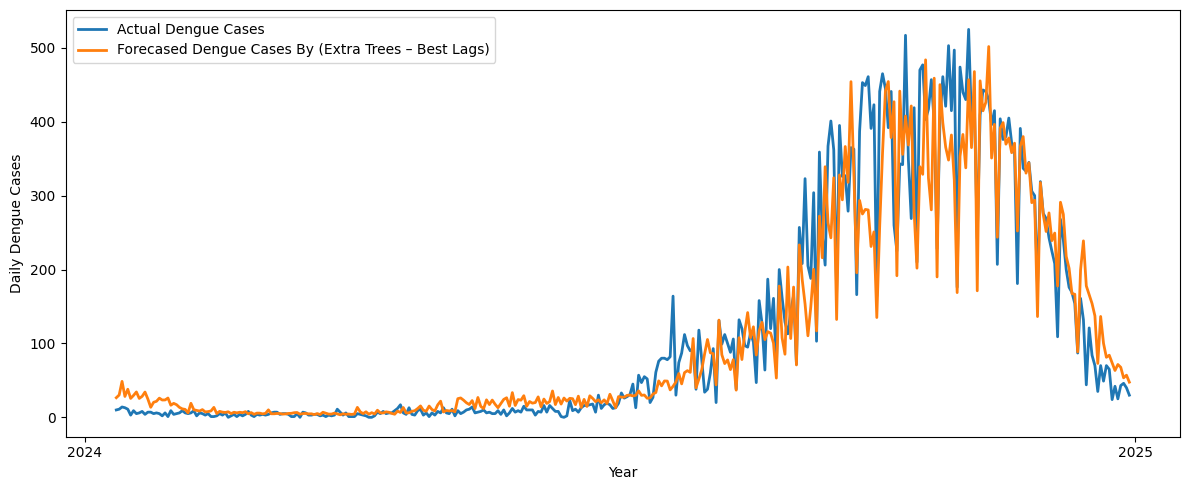

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1) Load data (file)

file_path = "/content/dhaka_dengue_weather_2020_2024.csv"
df = pd.read_csv(file_path)


# 2) Ensure Date index (robust)

date_candidates = ["Date", "date", "DATE", "Time", "time", "Datetime", "datetime"]

date_col = None
for c in date_candidates:
    if c in df.columns:
        date_col = c
        break

if date_col is None:
    first_col = df.columns[0]
    try:
        pd.to_datetime(df[first_col], errors="raise")
        date_col = first_col
    except Exception:
        date_col = None

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)
else:
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()


# 3) Validate required columns

target_col = "Dengue_Cases"
climate_cols = ["Temperature", "Humidity", "Rainfall_mm"]

missing = [c for c in [target_col] + climate_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nYour columns are: {list(df.columns)}")




# 4) Build DAILY series for dengue + climate (ensures all days exist)

df_daily = (
    df[[target_col] + climate_cols]
    .resample("D")
    .agg({
        target_col: "sum",
        "Temperature": "mean",
        "Humidity": "mean",
        "Rainfall_mm": "sum"
    })
    .asfreq("D")
)


df_daily[target_col] = df_daily[target_col].fillna(0)

# For climate variables, fill missing by forward fill (or interpolation)
df_daily["Temperature"] = df_daily["Temperature"].ffill()
df_daily["Humidity"] = df_daily["Humidity"].ffill()
df_daily["Rainfall_mm"] = df_daily["Rainfall_mm"].ffill()

print("Freq:", df_daily.index.inferred_freq)
print("Total days:", len(df_daily))


# 5) Create BEST lag features ( Spearman results)

df_daily["Temperature_Lag60"] = df_daily["Temperature"].shift(60)
df_daily["Humidity_Lag30"]    = df_daily["Humidity"].shift(30)
df_daily["Rainfall_Lag45"]    = df_daily["Rainfall_mm"].shift(45)

df_daily["Dengue_Lag7"]  = df_daily[target_col].shift(7)
df_daily["Dengue_Lag14"] = df_daily[target_col].shift(14)
df_daily["Dengue_Lag30"] = df_daily[target_col].shift(30)

features = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30",
]

df_ml = df_daily.dropna(subset=features + [target_col]).copy()

X = df_ml[features]
y = df_ml[target_col]


# 6) 80/20 chronological split

split_index = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train date range:", y_train.index.min(), "to", y_train.index.max())
print("Test  date range:", y_test.index.min(),  "to", y_test.index.max())


# 7) Train Extra Trees

etr = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
etr.fit(X_train, y_train)


# 8) Predict + Metrics

y_pred = np.clip(etr.predict(X_test), 0, None)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\nExtra Trees Forecast (80/20 Split)")
print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")


# 9) Plot actual vs predicted

forecast_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred}, index=y_test.index)

plt.figure(figsize=(12, 5))
plt.plot(forecast_df.index, forecast_df["Actual"], label="Actual Dengue Cases", linewidth=2)
plt.plot(
    forecast_df.index,
    forecast_df["Predicted"],
    label="Forecased Dengue Cases By (Extra Trees – Best Lags)",
    linewidth=2
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xlabel("Year")
plt.ylabel("Daily Dengue Cases")
#plt.title("Extra Trees Forecast (80/20 Split) – Actual vs Predicted (2020–2024)")
plt.legend()
plt.tight_layout()

# --------------------------------------------------
# 10) Save Plot (PNG + PDF)
# --------------------------------------------------
png_file = "ExtraTrees_Forecast_Actual_vs_Predicted_2020_2024.png"
pdf_file = "ExtraTrees_Forecast_Actual_vs_Predicted_2020_2024.pdf"

#plt.savefig(png_file, dpi=600, bbox_inches="tight")
#plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

print(f"Files saved as:\n{png_file}\n{pdf_file}")

plt.show()


Extra Trees trained on FULL 2020–2024 data (BEST LAGS).
Saved:
ExtraTrees_Dengue_Projection_2027.png
ExtraTrees_Dengue_Projection_2027.pdf


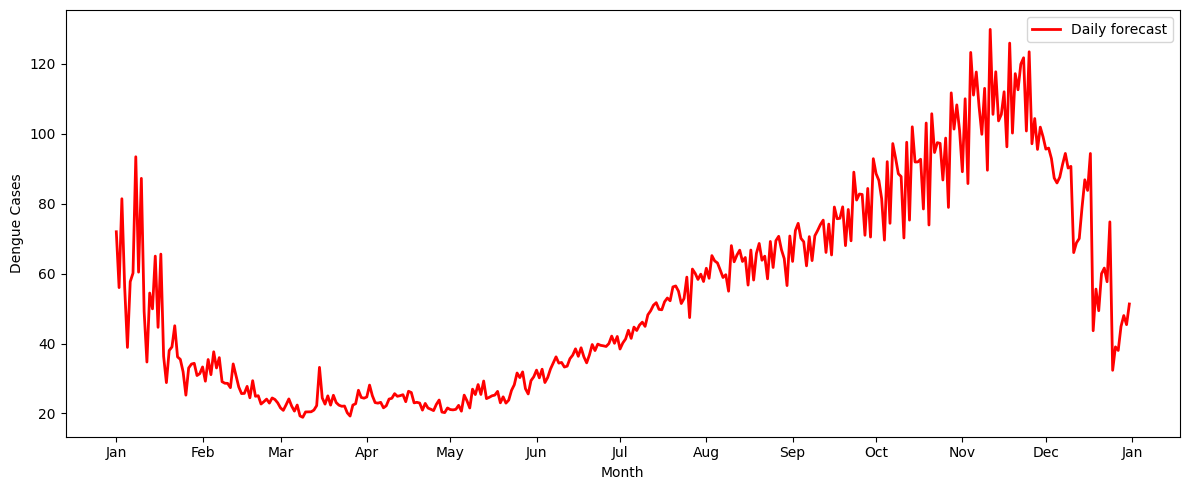

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.ensemble import ExtraTreesRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# 1) Load & Prepare Data (DAILY, continuous index)
# ============================================================
df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Aggregate (if multiple rows per day)
df = df.groupby("Date", as_index=False).agg({
    "Dengue_Cases": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Rainfall_mm": "sum"
})
df = df.set_index("Date").sort_index()

# Force a complete daily index for the entire historical range
full_hist_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
df_daily = df.reindex(full_hist_index)

# Fill dengue missing as 0
df_daily["Dengue_Cases"] = df_daily["Dengue_Cases"].fillna(0)

# Fill climate missing
df_daily["Temperature"] = df_daily["Temperature"].interpolate().ffill().bfill()
df_daily["Humidity"]    = df_daily["Humidity"].interpolate().ffill().bfill()
df_daily["Rainfall_mm"] = df_daily["Rainfall_mm"].fillna(0)

target_col = "Dengue_Cases"

# ============================================================
# 2) Create lag features
# ============================================================
df_daily["Temperature_Lag60"] = df_daily["Temperature"].shift(60)
df_daily["Humidity_Lag30"]    = df_daily["Humidity"].shift(30)
df_daily["Rainfall_Lag45"]    = df_daily["Rainfall_mm"].shift(45)

df_daily["Dengue_Lag7"]  = df_daily[target_col].shift(7)
df_daily["Dengue_Lag14"] = df_daily[target_col].shift(14)
df_daily["Dengue_Lag30"] = df_daily[target_col].shift(30)

feature_cols = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30"
]

df_ml = df_daily.dropna(subset=feature_cols + [target_col]).copy()
X_full = df_ml[feature_cols]
y_full = df_ml[target_col]

# ============================================================
# 3) Train Extra Trees on ALL historical data
# ============================================================
etr_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
etr_model.fit(X_full, y_full)
print("Extra Trees trained on FULL 2020–2024 data (BEST LAGS).")

# ============================================================
# 4) Forecast climate only for 2027
# ============================================================
forecast_start = pd.Timestamp("2027-01-01")
forecast_end   = pd.Timestamp("2027-12-31")
future_index   = pd.date_range(forecast_start, forecast_end, freq="D")

climate_future = pd.DataFrame(index=future_index)

def hw_forecast(series, steps, seasonal_periods=365, seasonal="add"):
    model = ExponentialSmoothing(
        series,
        trend=None,
        seasonal=seasonal,
        seasonal_periods=seasonal_periods,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    return fit.forecast(steps)

# Forecast Temperature & Humidity
for col in ["Temperature", "Humidity"]:
    climate_future[col] = np.array(
        hw_forecast(df_daily[col], steps=len(future_index), seasonal_periods=365, seasonal="add")
    )

# Forecast Rainfall
rf_fc = hw_forecast(df_daily["Rainfall_mm"], steps=len(future_index), seasonal_periods=365, seasonal="add")
climate_future["Rainfall_mm"] = np.clip(np.array(rf_fc), 0, None)

# Combine historical + future climate
climate_all = pd.concat([df_daily[["Temperature", "Humidity", "Rainfall_mm"]], climate_future], axis=0)
climate_all = climate_all.reindex(pd.date_range(climate_all.index.min(), climate_all.index.max(), freq="D"))
climate_all["Temperature"] = climate_all["Temperature"].interpolate().ffill().bfill()
climate_all["Humidity"]    = climate_all["Humidity"].interpolate().ffill().bfill()
climate_all["Rainfall_mm"] = climate_all["Rainfall_mm"].fillna(0)

# ============================================================
# 5) Recursive dengue forecasting for 2027 only
# ============================================================
lag_buffer = df_daily[target_col].iloc[-60:].tolist()

preds = []
for dt in future_index:
    t60 = dt - pd.Timedelta(days=60)
    t30 = dt - pd.Timedelta(days=30)
    t45 = dt - pd.Timedelta(days=45)

    row = {
        "Temperature_Lag60": float(climate_all.loc[t60, "Temperature"]),
        "Humidity_Lag30":    float(climate_all.loc[t30, "Humidity"]),
        "Rainfall_Lag45":    float(climate_all.loc[t45, "Rainfall_mm"]),
        "Dengue_Lag7":       float(lag_buffer[-7]),
        "Dengue_Lag14":      float(lag_buffer[-14]),
        "Dengue_Lag30":      float(lag_buffer[-30]),
    }

    X_row = pd.DataFrame([row])[feature_cols]
    y_hat = float(etr_model.predict(X_row)[0])
    y_hat = max(0.0, y_hat)

    preds.append(y_hat)
    lag_buffer.append(y_hat)
    lag_buffer = lag_buffer[-60:]

future_forecast = pd.DataFrame({"Predicted_Dengue": preds}, index=future_index)

# ============================================================
# 6) Plot 2027 only
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(
    future_forecast.index,
    future_forecast["Predicted_Dengue"],
    color="red",
    linewidth=2,
    label="Daily forecast"
)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.xlabel("Month")
plt.ylabel("Dengue Cases")
plt.legend()
plt.tight_layout()

png_file = "ExtraTrees_Dengue_Projection_2027.png"
pdf_file = "ExtraTrees_Dengue_Projection_2027.pdf"

plt.savefig(png_file, dpi=600, bbox_inches="tight")
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

print(f"Saved:\n{png_file}\n{pdf_file}")
plt.show()

In [ ]:
from google.colab import files

# Download PNG
files.download(png_file)

# Download PDF
files.download(pdf_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Projection of Dengue Cases (2027–2028) Using Extra Trees with Climate Forecast Integration**

Projection of Dengue Cases (2027–2028) Using Extra Trees with Climate Forecast Integration

In this analysis, a machine learning–based projection framework was developed to estimate future daily dengue cases for the years 2027–2028. The workflow begins by loading and preparing the historical dataset (2020–2024), ensuring a continuous daily time index. If multiple observations existed per day, they were aggregated by summing dengue cases and averaging (or summing) the respective climate variables. Missing dengue records were treated as zero cases, while missing climate values were interpolated and forward/backward filled to preserve continuity.

Based on prior lagged correlation (Spearman) analysis, biologically meaningful lag features were engineered. Specifically, temperature and rainfall were lagged by 60 days, humidity by 30 days, and dengue autoregressive terms were included at 7, 14, and 30 days. These lags reflect incubation periods, vector life cycles, and delayed environmental effects on transmission dynamics. Rows containing missing values resulting from lagging were removed before modeling.

An Extra Trees Regressor was then trained using the full historical dataset (2020–2024) and the selected lag features. This model captures nonlinear relationships between climate variables, past dengue incidence, and current dengue counts.

**Because future climate observations are unavailable, climate variables for 2025–2028 were projected using the Holt-Winters (Exponential Smoothing) method with yearly seasonality (365-day seasonal cycle). Temperature and humidity were forecast using additive seasonality, while rainfall forecasts were constrained to non-negative values. The projected climate series were then combined with historical climate data to form a continuous daily climate dataset extending into the future.**

Using this projected climate data, recursive dengue forecasting was performed. For each future day, lagged climate values (30- and 60-day delays) were retrieved, along with autoregressive dengue lags (7, 14, and 30 days) from a rolling buffer. The Extra Trees model then predicted dengue cases for that day. Each predicted value was appended to the lag buffer, allowing subsequent predictions to incorporate previously forecasted dengue values. This recursive process continued through 2028.

Finally, the projection results were restricted to 2027–2028 for visualization. Daily projected dengue cases were plotted with yearly axis formatting and saved as both PNG and PDF files.

Overall, this modeling strategy integrates:

Machine learning (Extra Trees) for dengue prediction

Time series forecasting (Holt-Winters) for future climate variables

Biologically informed lag structures

Recursive forecasting to simulate realistic future transmission dynamics

This approach provides a structured and defensible framework for long-term dengue projection under expected seasonal climate patterns.

In [ ]:
print("Mean:", df["Dengue_Cases"].mean())
print("Variance:", df["Dengue_Cases"].var())


Mean: 151.81927710843374
Variance: 51355.74266380601


In [ ]:
split_index = int(len(df_ml) * 0.8)


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1) Prepare Data
# ============================================================

df = pd.read_csv("/content/dhaka_dengue_weather_2020_2024.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Aggregate if multiple districts / entries per day
df = df.groupby("Date", as_index=False).agg({
    "Dengue_Cases": "sum",
    "Temperature": "mean",
    "Humidity": "mean",
    "Rainfall_mm": "sum"
})

df = df.set_index("Date").sort_index()

target_col = "Dengue_Cases"

# ============================================================
# 2) Create BEST Lag Features (from your Spearman results)
#    Temp -> 60 days, Humidity -> 30 days, Rainfall -> 45 days
#    Dengue autoregressive -> 7, 14, 30 days
# ============================================================

df["Temperature_Lag60"] = df["Temperature"].shift(60)
df["Humidity_Lag30"]    = df["Humidity"].shift(30)
df["Rainfall_Lag45"]    = df["Rainfall_mm"].shift(45)

df["Dengue_Lag7"]  = df[target_col].shift(7)
df["Dengue_Lag14"] = df[target_col].shift(14)
df["Dengue_Lag30"] = df[target_col].shift(30)

feature_cols = [
    "Temperature_Lag60",
    "Humidity_Lag30",
    "Rainfall_Lag45",
    "Dengue_Lag7",
    "Dengue_Lag14",
    "Dengue_Lag30"
]

# Drop rows with NaN (due to lagging)
df_model = df.dropna(subset=feature_cols + [target_col]).copy()

X = df_model[feature_cols]
y = df_model[target_col]

# ============================================================
# 3) Time-based Train / Test Split (~80% train)
# ============================================================

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Train size: {len(X_train)} days  |  Test size: {len(X_test)} days")
print(f"Test starts ≈ {X_test.index[0].date()}")

# Add constant (intercept)
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

# ============================================================
# 4) Fit Negative Binomial on TRAIN only
# ============================================================

nb_model = sm.GLM(
    y_train,
    X_train_const,
    family=sm.families.NegativeBinomial()
)

nb_results = nb_model.fit()

print("\nNegative Binomial Model Summary (Best Lags, fitted on training data):")
print(nb_results.summary())

# ============================================================
# 5) Predict on TEST set
# ============================================================

y_pred_nb = nb_results.predict(X_test_const)

# ============================================================
# 6) Evaluation Metrics
# ============================================================

mse_nb  = mean_squared_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mse_nb)
mae_nb  = mean_absolute_error(y_test, y_pred_nb)
r2_nb   = r2_score(y_test, y_pred_nb)

# MAPE - safe version (ignores zero actuals)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_nb = mean_absolute_percentage_error(y_test, y_pred_nb)

# SMAPE - symmetric & more robust for zeros
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0
    if np.sum(mask) == 0:
        return np.nan
    diff = np.abs(y_true[mask] - y_pred[mask])
    denom = denominator[mask]
    return 200 * np.mean(diff / denom)

smape_nb = symmetric_mean_absolute_percentage_error(y_test, y_pred_nb)

# ------------------------------------------------
# Print results
# ------------------------------------------------
print("\nNegative Binomial Performance on Test Set (Best Lags)")
print("──────────────────────────────────────────")
print(f"{'MSE:':<10} {mse_nb:,.4f}")
print(f"{'RMSE:':<10} {rmse_nb:,.4f}")
print(f"{'MAE:':<10} {mae_nb:,.4f}")
print(f"{'MAPE:':<10} {mape_nb:6.2f}%   (ignores days with 0 cases)")
print(f"{'SMAPE:':<10} {smape_nb:6.2f}%")
print(f"{'R²:':<10} {r2_nb:.4f}")
print(f"{'Mean actual cases (test):':<28} {y_test.mean():.2f}")


Train size: 1412 days  |  Test size: 354 days
Test starts ≈ 2024-01-12

Negative Binomial Model Summary (Best Lags, fitted on training data):
                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                 1412
Model:                            GLM   Df Residuals:                     1405
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7473.2
Date:                Tue, 17 Feb 2026   Deviance:                       2036.4
Time:                        08:18:28   Pearson chi2:                 4.72e+03
No. Iterations:                    17   Pseudo R-squ. (CS):             0.8095
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [

In [ ]:
!python --version

Python 3.12.12
